In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Funciones auxiliares

In [2]:
def plot_mesh(ax, xm, ym, ls='-', c='k', lw=0.75):
    '''
    Dibuja una malla usando las coordenadas xm y ym
    '''
    for y in ym:
        ax.plot([xm[0],xm[-1]], [y,y], color = c, ls = ls, lw = lw)
    for x in xm:
        ax.plot([x,x], [ym[0],ym[-1]], color = c, ls = ls, lw = lw)

In [28]:
def axisCustom(ax, Lx, Ly, x, y, titulo, cbar=False, ticks=[]):
    '''
    Personaliza los ejes y ajusta las gráficas.
    '''
    ax.set_title(titulo)
    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.set_yticks(y)
    ax.set_yticklabels([])
    lmax = max(Lx,Ly)
    offx = lmax * 0.1
    offy = lmax * 0.1
    ax.set_xlim(-offx, Lx+offx)
    ax.set_ylim(-offy, Ly+offy)
    ax.set_aspect('equal')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", "5%", pad="3%")
    cax.set_xticks([])
    cax.set_yticks([])
    if cbar:
        fig.colorbar(c, cax=cax, ticks=ticks, orientation='vertical')


In [20]:
def campoEscalar(NX, NY, LX, LY, X, Y, bc=[]):
    '''
    Definición de un campo escalar sobre una malla dada.
    '''
    # Definición del campo escalar
    S = np.zeros((NX, NY))
    for i in range(NX):
        for j in range(NY):
            S[i,j] = i / NX

    # Valores en las fronteras del dominio
    SL = bc[0]; SR = bc[1]
    SB = bc[2]; ST = bc[3]
    S[0 , :] = SL # LEFT
    S[-1, :] = SR # RIGHT
    S[: , 0] = SB # BOTTOM
    S[: ,-1] = ST # TOP

    # Dos puntos especiales en el dominio
    S[NX//3, NY//3] = ST
    S[2*NX//3, 2*NY//3] = ST
    
    print('x shape: ', X.shape, 'y shape: ', Y.shape, 'Scalar shape: ', S.shape)
    
    return S

In [21]:
def campoVectorial(NX, NY, LX, LY, X, Y):
    '''
    Definición de un campo vectorial sobre una malla dada.
    '''
    # Definición del campo vectorial (en este caso dos valores por nodo)
    V = np.zeros((2, NX, NY))
    A = 1.0
    alpha_x = 1.0
    alpha_y = 1.0
    
    V[0] = -A * np.cos(np.pi * alpha_y * Y / LY) * np.sin(np.pi * alpha_x * X / LX)
    V[0][0,:] = 0.0
    V[0][:,0] = 0.0
    V[0][-1,:] = 0.0
    V[0][:,-1] = 0.0
    
    V[1] =  A * np.sin(np.pi * alpha_y * Y / LY) * np.cos(np.pi * alpha_x * X / LX)
    V[1][0,:] = 0.0
    V[1][:,0] = 0.0
    V[1][-1,:] = 0.0
    V[1][:,-1] = 0.0
    
    print('x shape: ', X.shape, 'y shape: ', Y.shape, 'Vectorial shape :', V.shape)
    
    return V

# Configuración y numeración de los nodos y volúmenes

In [22]:
#                                             
# 0       1       2       3       4       5   Nx  = 4 (nodos interiores)
# |                                       |   Nvx = 5 (total de volúmenes)
# *---*---|---*---|---*---|---*---|---*---*   hx = L / Nx + 1 = L / Nvx 
# |                                       |   NxT = 6 (total de nodos: interiores + fronteras) 
# 0   1       2       3       4       5   6   NvxT = 7 (total de volúmenes + fronteras)
#                                             
#  <----------------- L ------------------>  
#
Nx   = 4 # Nodos interiores en x
Ny   = 5 # Nodos interiores en y
Nvx  = Nx + 1 # Volúmenes en x
Nvy  = Ny + 1 # Volúmenes en y
Lx   = 1.0
Ly   = 1.0
hx   = Lx / (Nx+1)
hy   = Ly / (Ny+1)
NxT  = Nx + 2  # Número total de nodos en x incluyendo fronteras
NyT  = Ny + 2  # Número total de nodos en y incluyendo fronteras
NvxT = Nvx + 2 # Número total de volúmenes en x más las fronteras
NvyT = Nvy + 2 # Número total de volúmenes en y más las fronteras

# Coordenadas de nodos y volúmenes

Nodos
Coord. x:  [0.  0.2 0.4 0.6 0.8 1. ]
Coord. y:  [0.         0.16666667 0.33333333 0.5        0.66666667 0.83333333
 1.        ]
Volúmenes
Coord. x:  [0.  0.1 0.3 0.5 0.7 0.9 1. ]
Coord. y:  [0.         0.08333333 0.25       0.41666667 0.58333333 0.75
 0.91666667 1.        ]


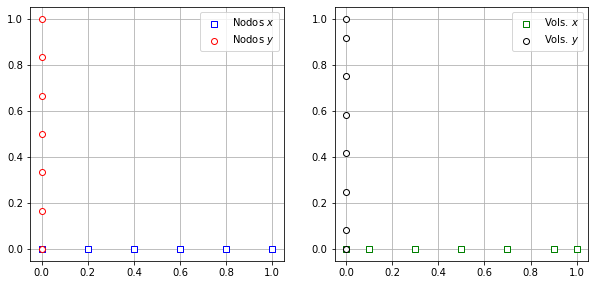

In [23]:
# Coordenadas para diferencias finitas (nodos)
xn = np.linspace(0,Lx,NxT)
yn = np.linspace(0,Ly,NyT)

# Coordenadas para volúmenes finitos (volúmenes)
xv = np.zeros(NvxT)
yv = np.zeros(NvyT)
xv[-1] = Lx
yv[-1] = Ly
xv[1:-1] = np.linspace(0.5*hx,Lx-0.5*hx,Nvx)
yv[1:-1] = np.linspace(0.5*hy,Ly-0.5*hy,Nvy)

print('Nodos')
print('Coord. x: ', xn)
print('Coord. y: ', yn)

print('Volúmenes')
print('Coord. x: ', xv)
print('Coord. y: ', yv)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

# Graficamos las coordenadas de los nodos sobre cada eje
ax1.scatter(xn, [0 for i in range(len(xn))], marker='s', fc = 'w', ec = 'b', label='Nodos $x$', zorder=5)
ax1.scatter([0 for i in range(len(yn))], yn, marker='o', fc = 'w', ec = 'r', label='Nodos $y$', zorder=5)
ax1.set_aspect('equal')
ax1.legend()
ax1.grid()

# Graficamos las coordenadas de los volúmenes sobre cada eje
ax2.scatter(xv, [0 for i in range(len(xv))], marker='s', fc = 'w', ec = 'g', label='Vols. $x$', zorder=5)
ax2.scatter([0 for i in range(len(yv))], yv, marker='o', fc = 'w', ec = 'k', label='Vols. $y$', zorder=5)
ax2.set_aspect('equal')
ax2.legend()
ax2.grid()

plt.show()

# Generación y graficación de las mallas para FDM y FVM

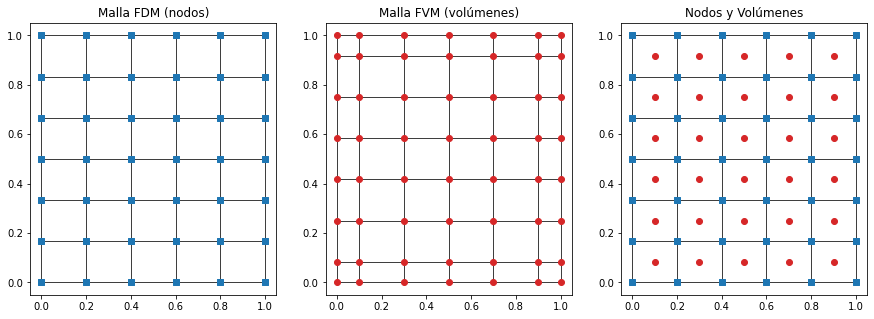

In [24]:
# Coordenadas de la malla para diferencias finitas
xg, yg = np.meshgrid(xn, yn, indexing='ij', sparse=False)

# Coordenadas de la malla para volúmenes finitos
xvg, yvg = np.meshgrid(xv, yv, indexing='ij', sparse=False)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

# Grafica la malla y nodos para FDM
ax1.scatter(xg, yg, c = 'C0', marker = 's', zorder=5)
ax1.set_title('Malla FDM (nodos)')
plot_mesh(ax1, xn, yn)

# Grafica la malla y volúmenes para FDM
ax2.scatter(xvg, yvg, c = 'C3', marker = 'o', zorder=5)
ax2.set_title('Malla FVM (volúmenes)')
plot_mesh(ax2, xv, yv)

# Grafica los nodos y volúmenes
ax3.scatter(xg, yg, c = 'C0', marker = 's', zorder=5)
ax3.scatter(xvg[1:-1, 1:-1], yvg[1:-1, 1:-1], c = 'C3', marker = 'o')
ax3.set_title('Nodos y Volúmenes')
plot_mesh(ax3, xn, yn)

plt.show()

# Generación y graficación de los campos escalar y vectorial para FDM

In [26]:
bc = [1.5, 2.5, 3.5, 4.5]
T = campoEscalar(NxT, NyT, Lx, Ly, xg, yg, bc)

v = campoVectorial(NxT, NyT, Lx, Ly, xg, yg)

x shape:  (6, 7) y shape:  (6, 7) Scalar shape:  (6, 7)
x shape:  (6, 7) y shape:  (6, 7) Vectorial shape : (2, 6, 7)


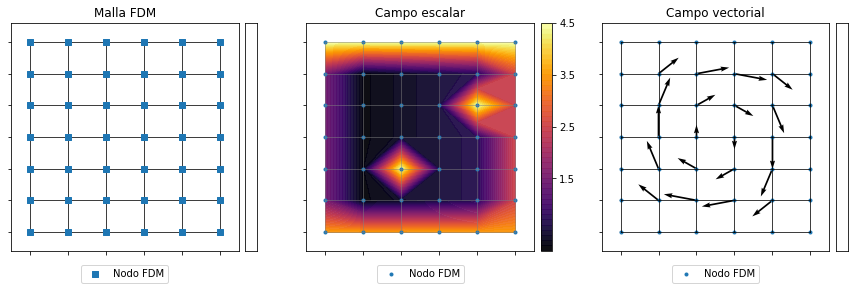

In [30]:
# Definición de la figura y de las subgráficas
fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharey='row', figsize=(15,5),
                        gridspec_kw={'hspace': 0, 'wspace': 0.2})

# Grafica de la malla
ax1.scatter(xg, yg, c = 'C0', marker = 's', zorder=5, label='Nodo FDM')
plot_mesh(ax1, xn, yn)
ax1.legend(loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax1, Lx, Ly, xn, yn, 'Malla FDM')

# Gráfica del campo escalar
c = ax2.contourf(xg, yg, T, levels=50, cmap='inferno', alpha=0.95)
plot_mesh(ax2, xn, yn, '-', 'gray', 0.5)
ax2.scatter(xg, yg, c = 'C0', marker = '.', label='Nodo FDM')
ax2.legend(loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax2, Lx, Ly, xn, yn, 'Campo escalar', cbar=True, ticks = bc)

# Gráfica del campo vectorial
ax3.quiver(xg, yg, v[0], v[1])
plot_mesh(ax3, xn, yn)
ax3.scatter(xg, yg, c = 'C0', marker = '.', label='Nodo FDM')
ax3.legend(loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax3, Lx, Ly, xn, yn, 'Campo vectorial')

plt.savefig('Campos_FDM.pdf', bbox_inches = 'tight')
plt.show()

# Generación y graficación de los campos escalar y vectorial para FVM

In [32]:
Tv = campoEscalar(NvxT, NvyT, Lx, Ly, xvg, yvg, bc)
vv = campoVectorial(NvxT, NvyT, Lx, Ly, xvg, yvg)

x shape:  (7, 8) y shape:  (7, 8) Scalar shape:  (7, 8)
x shape:  (7, 8) y shape:  (7, 8) Vectorial shape : (2, 7, 8)


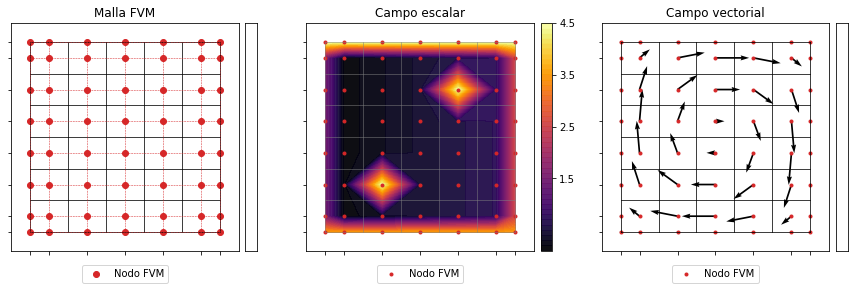

In [33]:
# Definición de la figura y de las subgráficas
fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharey='row', figsize=(15,5),
                        gridspec_kw={'hspace': 0, 'wspace': 0.2})

# Grafica de la malla
ax1.scatter(xvg, yvg, c = 'C3', marker = 'o', label='Volumen FVM')
plot_mesh(ax1, xn, yn)
plot_mesh(ax1, xv, yv, '--', 'C3', 0.5)
ax1.legend(loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax1, Lx, Ly, xv, yv, 'Malla FVM')

# Gráfica del campo escalar
c = ax2.contourf(xvg, yvg, Tv, levels=50, cmap='inferno', alpha=0.95)
plot_mesh(ax2, xn, yn, '-', 'gray', 0.5)
ax2.scatter(xvg, yvg, c = 'C3', marker = '.', label='Volumen FVM')
ax2.legend(loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax2, Lx, Ly, xv, yv, 'Campo escalar', cbar=True, ticks=bc)

# Gráfica del campo vectorial
ax3.quiver(xvg, yvg, vv[0], vv[1])
plot_mesh(ax3, xn, yn)
#plot_mesh(ax3, xv, yv, '--', 'C0', 0.5)
ax3.scatter(xvg, yvg, c = 'C3', marker = '.', label='Volumen FVM')
ax3.legend(loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax3, Lx, Ly, xv, yv, 'Campo vectorial')

plt.savefig('Campos_FVM.pdf', bbox_inches = 'tight')
plt.show()

# Velocidad recorrida (staggered)  para FVM

In [83]:
# Coordenadas de la malla recorrida en la dirección x
x_sx, y_sx = np.meshgrid(xn, yv, indexing='ij', sparse=False)

# Campo vectorial
vx = campoVectorial(NxT, NvyT, Lx, Ly, x_sx, y_sx) 
vx[1] = np.zeros((NxT, NvyT))                      # Componente y cero

# Coordenadas de la malla recorrida en la dirección y
x_sy, y_sy = np.meshgrid(xv, yn, indexing='ij', sparse=False)

# Campo vectorial
vy = campoVectorial(NvxT, NyT, Lx, Ly, x_sy, y_sy) 
vy[0] = np.zeros((NvxT, NyT))                      # Componente x cero 

x shape:  (6, 8) y shape:  (6, 8) Vectorial shape : (2, 6, 8)
x shape:  (7, 7) y shape:  (7, 7) Vectorial shape : (2, 7, 7)


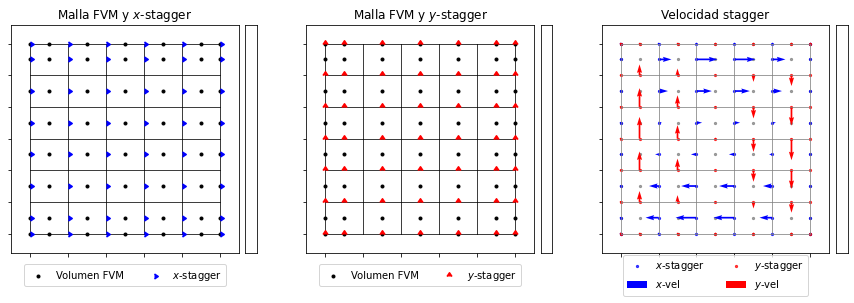

In [158]:
# Definición de la figura y de las subgráficas
fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharey='row', figsize=(15,5),
                        gridspec_kw={'hspace': 0, 'wspace': 0.2})

# Grafica de la malla y la velocidad x 
ax1.scatter(xvg, yvg, c = 'k', marker = '.', label='Volumen FVM')
ax1.scatter(x_sx, y_sx, marker=9, color='b', s=25, label='$x$-stagger', zorder=5)
plot_mesh(ax1, xn, yn)
ax1.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax1, Lx, Ly, xn, yv, 'Malla FVM y $x$-stagger')

# Grafica de la malla y la velocidad y
ax2.scatter(xvg, yvg, c = 'k', marker = '.', label='Volumen FVM')
ax2.scatter(x_sy, y_sy, marker=10, color='r', s=25, label='$y$-stagger', zorder=5)
plot_mesh(ax2, xn, yn)
ax2.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax2, Lx, Ly, xn, yv, 'Malla FVM y $y$-stagger')

# Grafica de la velocidad stagger
ax3.scatter(xvg, yvg, c = 'gray', marker = '.', alpha=0.75, s=20)
ax3.scatter(x_sx, y_sx, marker='.', color='b', alpha=0.75, s=20, label='$x$-stagger')
ax3.quiver(x_sx, y_sx, vx[0], vx[1], color='b', label='$x$-vel', scale=10)
ax3.scatter(x_sy, y_sy, marker='.', color='r', alpha=0.75, s=20, label='$y$-stagger')
ax3.quiver(x_sy, y_sy, vy[0], vy[1], color='r', label='$y$-vel', scale=10)
plot_mesh(ax3, xn, yn, '-', 'gray')
ax3.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax3, Lx, Ly, xn, yn, 'Velocidad stagger')

plt.savefig('Vel_stagger_FVM.pdf', bbox_inches = 'tight')
plt.show()

# Malla de volúmenes para las velocidades

In [165]:
xv_sx, yv_sy = np.meshgrid(xv, yv, indexing='ij', sparse=False)
xv_sx, yv_sy = np.meshgrid(xn, yv, indexing='ij', sparse=False)

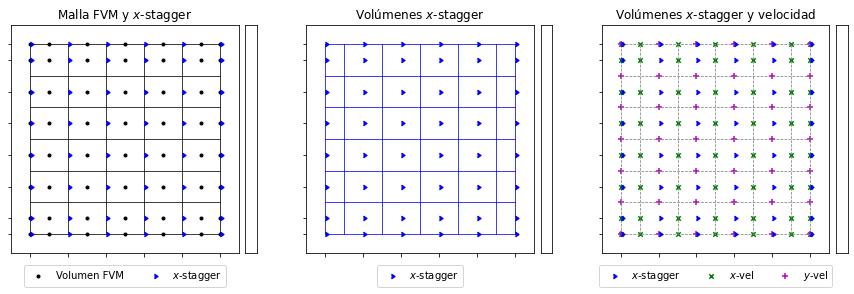

In [242]:
# Definición de la figura y de las subgráficas
fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharey='row', figsize=(15,5),
                        gridspec_kw={'hspace': 0, 'wspace': 0.2})

plot_mesh(ax1, xn, yn)
ax1.scatter(xvg, yvg, c = 'k', marker = '.', label='Volumen FVM')
ax1.scatter(x_sx, y_sx, marker=9, color='b', s=20,zorder=5, label='$x$-stagger')
ax1.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax1, Lx, Ly, xn, yn, 'Malla FVM y $x$-stagger')

ax2.scatter(x_sx, y_sx, marker=9, color='b', s=20, zorder=5, label='$x$-stagger')
plot_mesh(ax2, xv, yn, '-', 'b')
ax2.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax2, Lx, Ly, xn, yv, 'Volúmenes $x$-stagger')

ax3.scatter(x_sx, y_sx, marker=9, color='b', s=20, zorder=5, label='$x$-stagger')
plot_mesh(ax3, xv, yn, '--', 'gray')
ax3.scatter(xv_sx, yv_sy, marker='x', c='g', s=20, label='$x$-vel')
ax3.scatter(xg, yg, marker='+', c='m', s=30, label='$y$-vel')
ax3.legend(ncol=3, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax3, Lx, Ly, xn, yv, 'Volúmenes $x$-stagger y velocidad')

plt.savefig('Mesh_x_stagger_FVM.pdf', bbox_inches = 'tight')
plt.show()

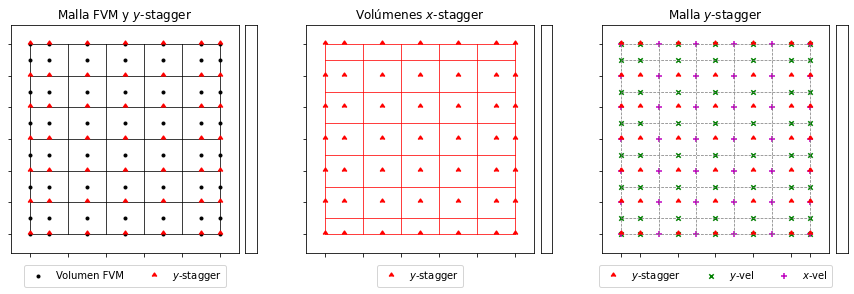

In [243]:
# Definición de la figura y de las subgráficas
fig, (ax1, ax2, ax3) = plt.subplots(1,3, sharey='row', figsize=(15,5),
                        gridspec_kw={'hspace': 0, 'wspace': 0.2})

plot_mesh(ax1, xn, yn)
ax1.scatter(xvg, yvg, c = 'k', marker = '.', label='Volumen FVM')
ax1.scatter(x_sy, y_sy, marker=10, color='r', s=20,zorder=5, label='$y$-stagger')
ax1.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax1, Lx, Ly, xn, yn, 'Malla FVM y $y$-stagger')

ax2.scatter(x_sy, y_sy, marker=10, color='r', s=20, zorder=5, label='$y$-stagger')
plot_mesh(ax2, xn, yv, '-', 'r')
ax2.legend(ncol=2, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax2, Lx, Ly, xn, yv, 'Volúmenes $x$-stagger')

ax3.scatter(x_sy, y_sy, marker=10, color='r', s=20, zorder=5, label='$y$-stagger')
plot_mesh(ax3, xn, yv, '--', 'gray')
ax3.scatter(xv_sx, yv_sy, marker='x', c='g', s=20, label='$y$-vel')
ax3.scatter(xg, yg, marker='+', c='m', s=30, label='$x$-vel')
ax3.legend(ncol=3, loc='center', bbox_to_anchor=(0.50, -0.1))
axisCustom(ax3, Lx, Ly, xv, yn, 'Malla $y$-stagger')

plt.savefig('Mesh_y_stagger_FVM.pdf', bbox_inches = 'tight')
plt.show()